In [62]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from torchvision import datasets, transforms
from PIL import Image
import torch
import os
from BIMT_2D import BioMLP2D

In [49]:
model_type = "vanilla"
json_file = json.load(open(f'results/{model_type}.json', 'r'))

json_file = dict(sorted(json_file.items(), key=lambda x: int(x[0])))

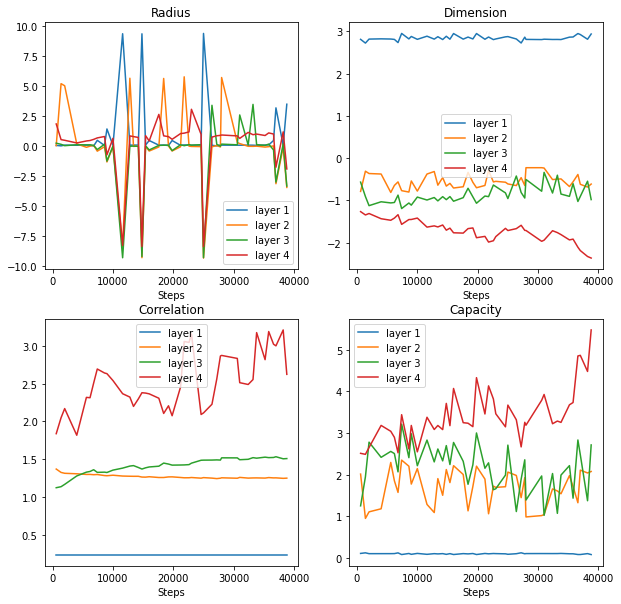

In [51]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
properties = ['radius', 'dimension', 'correlation', 'capacity']
titles = ['Radius', 'Dimension', 'Correlation', 'Capacity']

for i, prop in enumerate(properties):
    layers = [[], [], [], []]
    keys = []
    for key, value in json_file.items():
        if value == {}:
            continue
        for j in range(4):
            if prop in ['radius', 'dimension']:
                layers[j].append(np.log(value[prop][j]) if j == 0 else np.log(value[prop][j]/value[prop][0]))
            else:
                layers[j].append(value[prop][j] if j == 0 else value[prop][j]/value[prop][0])
        keys.append(int(key))
    ax[i//2, i%2].plot(keys, layers[0], label='layer 1')
    ax[i//2, i%2].plot(keys, layers[1], label='layer 2')
    ax[i//2, i%2].plot(keys, layers[2], label='layer 3')
    ax[i//2, i%2].plot(keys, layers[3], label='layer 4')
    ax[i//2, i%2].set_title(titles[i])
    ax[i//2, i%2].legend()
    ax[i//2, i%2].set_xlabel('Steps')

fig.savefig(f'results/{model_type}.jpg')

In [56]:
# Load MNIST test data
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
test_data = datasets.MNIST(root='./neural_manifolds_replicaMFT/mftma/data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=1000, shuffle=False)


100%|██████████| 9912422/9912422 [00:08<00:00, 1232685.44it/s]


Extracting ./neural_manifolds_replicaMFT/mftma/data/MNIST/raw/train-images-idx3-ubyte.gz to ./neural_manifolds_replicaMFT/mftma/data/MNIST/raw



100%|██████████| 28881/28881 [00:00<00:00, 24853445.59it/s]

Extracting ./neural_manifolds_replicaMFT/mftma/data/MNIST/raw/train-labels-idx1-ubyte.gz to ./neural_manifolds_replicaMFT/mftma/data/MNIST/raw



100%|██████████| 1648877/1648877 [00:00<00:00, 2041901.99it/s]


Extracting ./neural_manifolds_replicaMFT/mftma/data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./neural_manifolds_replicaMFT/mftma/data/MNIST/raw



100%|██████████| 4542/4542 [00:00<00:00, 8939713.17it/s]

Extracting ./neural_manifolds_replicaMFT/mftma/data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./neural_manifolds_replicaMFT/mftma/data/MNIST/raw



In [58]:

# Function to get PCA components and labels
def get_pca_components(model, data_loader):
    for images, labels in data_loader:
        output = model(images)
        pca = PCA(n_components=2)
        components = pca.fit_transform(output.detach().numpy())
        return components, labels.numpy()

# Function to plot PCA components
def plot_pca(components, labels, step):
    scatter = plt.scatter(components[:, 0], components[:, 1], c=labels, cmap='tab10')
    plt.title(f'PCA Decomposition - Step {step}')
    plt.colorbar(scatter, ticks=range(10), label='Digit')
    plt.savefig(f'pca_plots/pca_{step}.png')
    plt.close()




In [60]:
!ls

BIMT.py                          data
BIMT_2D.py                       manifold_analysis_correlation.py
BIMT_manifolds.ipynb             models
BIMT_manifolds.py                neural_manifolds_replicaMFT
MFTMA_VGG16_example.ipynb        res_pca
__pycache__                      res_tsne
alldata_dimension_analysis.py    results
analyse_data.ipynb               utils
analyze_pytorch.py


FileNotFoundError: [Errno 2] No such file or directory: 'pca_plots/pca_200.png'

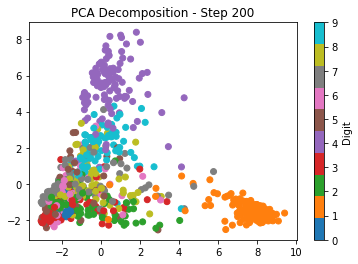

In [67]:
# Load models and create PCA plots
base_dir = f'models/{model_type}_cnn'
model_paths = sorted(os.listdir(base_dir), key=lambda x: int(x.split('-')[0]))
model = BioMLP2D(shp=[784, 100, 100, 10])
for model_path in model_paths:
    model.load_state_dict(torch.load(base_dir + "/" + model_path, map_location=torch.device('cpu')))
    components, labels = get_pca_components(model, test_loader)
    step = int(model_path.split('-')[0])
    plot_pca(components, labels, step)

# Create GIF
images = [Image.open(f'pca_plots/{img}') for img in sorted(os.listdir('pca_plots'), key=lambda x: int(x.split('_')[-1].split('.')[0]))]
images[0].save('pca.gif', save_all=True, append_images=images[1:], loop=0, duration=200)